# MODELING (Xây dựng mô hình)
Trong phần này, chúng ta sẽ xây dựng các mô hình máy học để dự đoán khả năng nghỉ việc (Attrition) của nhân viên. Quy trình thực hiện:

1. Phân chia tập dữ liệu (Train/Test Split).
2. Xây dựng các mô hình cơ sở.
3. Tối ưu hóa tham số.
4. Trực quan hóa cây quyết định để giải thích.

### 1. Khởi tạo và Đọc dữ liệu
Đầu tiên, tải các thư viện cần thiết và đọc dữ liệu đã được xử lý từ bước Feature.

- **Scaled Data**: Dùng cho các thuật toán nhạy cảm với khoảng cách (KNN, SVM, Logistic Regression).
- **Not Scaled Data**: Dùng cho các thuật toán cây (Decision Tree, Random Forest) để giữ nguyên tính giải thích của đặc trưng gốc.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Các thư viện Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Các thư viện đánh giá
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Đọc dữ liệu
# 1. Dữ liệu đã Scale (Dùng cho Logistic Regression, SVM, KNN)
df_scaled = pd.read_csv('HR_Analytics_Selected_Scaled.csv')

# 2. Dữ liệu chưa Scale (Dùng cho Decision Tree / Random Forest để giữ nguyên ý nghĩa gốc của dữ liệu)
df_not_scaled = pd.read_csv('HR_Analytics_Selected_NotScaled.csv')

print("Kích thước của bộ dữ liệu Scaled :", df_scaled.shape)
print("Kích thước của bộ dữ liệu chưa Scaled:", df_not_scaled.shape)

Kích thước của bộ dữ liệu Scaled : (1470, 26)
Kích thước của bộ dữ liệu chưa Scaled: (1470, 26)


### 2. Phân chia tập dữ liệu (Train - Test Split)
Chúng ta chia dữ liệu theo tỷ lệ **80% Train - 20% Test**, có sử dụng `stratify` để đảm bảo tỷ lệ nhân viên nghỉ việc được chia đều giữa hai tập.

In [43]:
# Xác định biến mục tiêu và biến độc lập
target = 'Attrition'

# Dữ liệu Scaled
X_scaled = df_scaled.drop(target, axis=1)
y_scaled = df_scaled[target]

X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, stratify=y_scaled
)

# Dữ liệu Not Scaled (Cho Tree-based models)
X_not_scaled = df_not_scaled.drop(target, axis=1)
y_not_scaled = df_not_scaled[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_not_scaled, y_not_scaled, test_size=0.2, random_state=42, stratify=y_not_scaled
)

print(f"Train size: {X_train_sc.shape[0]}, Test size: {X_test_sc.shape[0]}")

Train size: 1176, Test size: 294


### 3. Xây dựng Mô hình Cơ sở
Chúng ta sẽ thử nghiệm các nhóm thuật toán khác nhau:

1. Linear & Distance-based (Logistic Regression, SVM, KNN): Dùng `X_train_sc`.
2. Tree-based (Decision Tree, Random Forest): Dùng `X_train_raw` (để dễ giải thích feature importances).

#### 3.1. Nhóm thuật toán dựa trên khoảng cách (Distance-based)
_(Sử dụng dữ liệu đã chuẩn hóa - Scaled)_

In [44]:
# Khởi tạo các mô hình
models_sc = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced'),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

results = {}

for name, model in models_sc.items():
    # Huấn luyện
    model.fit(X_train_sc, y_train_sc)
    
    # Dự đoán
    y_pred = model.predict(X_test_sc)
    
    # Lưu kết quả accuracy cơ bản
    acc = accuracy_score(y_test_sc, y_pred)
    results[name] = acc
    
    print(f"--- {name} ---")
    print(classification_report(y_test_sc, y_pred))
    print("-" * 30)

--- Logistic Regression ---
              precision    recall  f1-score   support

         0.0       0.94      0.72      0.82       247
         1.0       0.34      0.74      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.73      0.76       294

------------------------------
--- Support Vector Machine ---
              precision    recall  f1-score   support

         0.0       0.92      0.84      0.88       247
         1.0       0.43      0.64      0.52        47

    accuracy                           0.81       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.85      0.81      0.82       294

------------------------------
--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90       247
         1.0       0.35      0.13      0.19        47

    accuracy                     

#### 3.2. Nhóm mô hình cây quyết định (Tree-based Models)
_Sử dụng dữ liệu gốc (chưa scale)_ để khi xem xét độ quan trọng của biến (Feature Importance), các giá trị như "MonthlyIncome" hay "Age" giữ nguyên đơn vị thực tế.

In [45]:
models_tree = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'), # Giới hạn depth để tránh Overfitting
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

for name, model in models_tree.items():
    # Huấn luyện trên dữ liệu RAW
    model.fit(X_train_raw, y_train_raw)
    
    # Dự đoán
    y_pred = model.predict(X_test_raw)
    
    # Lưu kết quả
    acc = accuracy_score(y_test_raw, y_pred)
    results[name] = acc
    
    print(f"--- {name} ---")
    print(classification_report(y_test_raw, y_pred))

--- Decision Tree ---
              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82       247
         1.0       0.31      0.55      0.39        47

    accuracy                           0.73       294
   macro avg       0.60      0.66      0.61       294
weighted avg       0.80      0.73      0.76       294

--- Random Forest ---
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91       247
         1.0       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



### 4. Tối ưu hóa Mô hình

Dựa trên kết quả cơ sở, **Random Forest** thường cho thấy tiềm năng tốt nhất nhưng dễ bị Overfitting. Chúng ta sẽ sử dụng kỹ thuật `GridSearchCV` với chế độ kiểm soát chặt chẽ (Strong Regularization) để tìm ra bộ tham số tối ưu, giúp mô hình ổn định trên tập dữ liệu nhỏ và mất cân bằng.

In [46]:
param_grid = {
    # 1. Ép cây cực nông (chỉ sâu 3-5 tầng)
    # Cây càng nông thì càng ít khả năng học vẹt
    'max_depth': [3, 4, 5], 
    
    # 2. Bắt buộc mỗi lá phải chứa rất nhiều mẫu (15-30 người)
    # Điều này ngăn mô hình tạo quy luật riêng cho nhóm nhỏ
    'min_samples_leaf': [15, 25, 30],   
    
    # 3. Giới hạn số lượng features được nhìn thấy ở mỗi lần tách
    # 'sqrt': căn bậc 2 số features, 0.3: chỉ nhìn 30% số features
    # Giúp cây bớt phụ thuộc vào vài feature mạnh (như MonthlyIncome)
    'max_features': ['sqrt', 0.3],
    
    # 4. Giữ nguyên class_weight
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            
    scoring='f1',    
    n_jobs=-1,
    verbose=1
)

print("Đang chạy GridSearch...")
rf_grid.fit(X_train_raw, y_train_raw)

print("Best Params:", rf_grid.best_params_)
print("Best F1 Score:", rf_grid.best_score_)

best_rf_model = rf_grid.best_estimator_

Đang chạy GridSearch...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 30}
Best F1 Score: 0.49534321311829854


### 5. Kiểm định độ ổn định
Bước này nhằm đảm bảo mô hình không bị hiện tượng "học vẹt" (Overfitting). Chúng ta so sánh chỉ số F1-Score giữa tập Train và tập Test. Một mô hình tốt là mô hình có khoảng cách giữa Train và Test không quá lớn.

In [47]:
from sklearn.metrics import accuracy_score, f1_score

# Dự đoán trên tập Train và Test
y_train_pred = best_rf_model.predict(X_train_raw)
y_test_pred = best_rf_model.predict(X_test_raw)

# Tính toán các chỉ số
train_acc = accuracy_score(y_train_raw, y_train_pred)
test_acc = accuracy_score(y_test_raw, y_test_pred)

train_f1 = f1_score(y_train_raw, y_train_pred)
test_f1 = f1_score(y_test_raw, y_test_pred)

print(f"--- KẾT QUẢ KIỂM TRA OVERFITTING ---")
print(f"Training Accuracy: {train_acc:.4f} | Training F1-Score: {train_f1:.4f}")
print(f"Test Accuracy:     {test_acc:.4f} | Test F1-Score:     {test_f1:.4f}")
print("-" * 50)

# Đánh giá nhanh
if train_f1 - test_f1 > 0.15:
    print("CẢNH BÁO: Mô hình có dấu hiệu Overfitting (F1 trên Train cao hơn nhiều so với Test).")
else:
    print("ỔN ĐỊNH: Mô hình hoạt động khá đồng đều trên cả tập Train và Test.")

--- KẾT QUẢ KIỂM TRA OVERFITTING ---
Training Accuracy: 0.8401 | Training F1-Score: 0.5747
Test Accuracy:     0.7959 | Test F1-Score:     0.4737
--------------------------------------------------
ỔN ĐỊNH: Mô hình hoạt động khá đồng đều trên cả tập Train và Test.


### 6. Phân tích yếu tố ảnh hưởng (Feature Importance)
Sau khi có được mô hình tối ưu, chúng ta trích xuất mức độ quan trọng của các đặc trưng để trả lời câu hỏi: "Yếu tố nào tác động mạnh nhất đến quyết định nghỉ việc của nhân viên?".

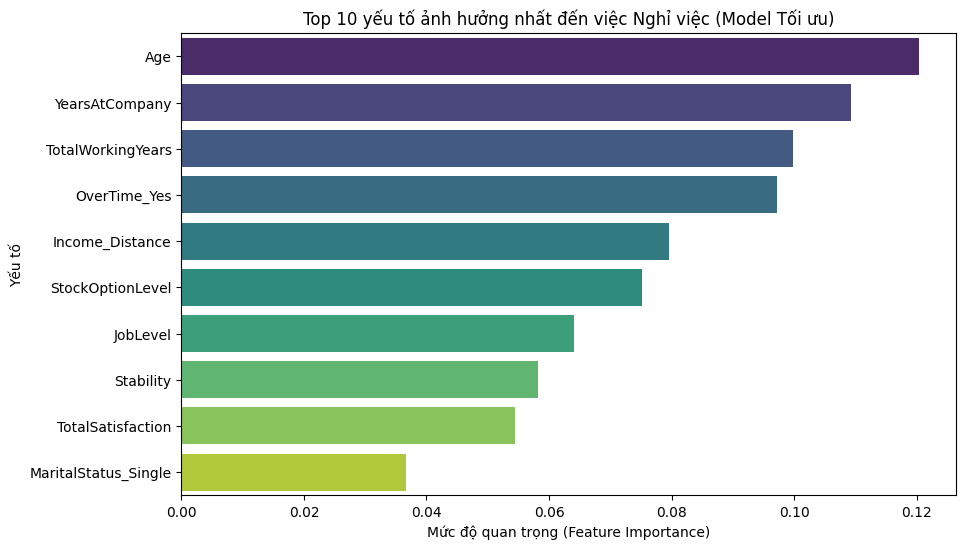

Các yếu tố quan trọng nhất:
                 Feature  Importance
3                    Age    0.120468
9         YearsAtCompany    0.109296
5      TotalWorkingYears    0.099771
1           OverTime_Yes    0.097183
0        Income_Distance    0.079632
12      StockOptionLevel    0.075109
14              JobLevel    0.064135
11             Stability    0.058245
6      TotalSatisfaction    0.054412
22  MaritalStatus_Single    0.036662


In [48]:
# Lấy mức độ quan trọng từ model tốt nhất đã tìm được
importances = best_rf_model.feature_importances_
feature_names = X_train_raw.columns

# Tạo DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10) # Lấy Top 10

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue = 'Feature', legend=False)
plt.title('Top 10 yếu tố ảnh hưởng nhất đến việc Nghỉ việc (Model Tối ưu)')
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.ylabel('Yếu tố')
plt.show()

# In ra số liệu cụ thể để bạn viết báo cáo
print("Các yếu tố quan trọng nhất:")
print(feature_imp_df)

### 7. Lưu trữ Mô hình
Lưu mô hình đã huấn luyện ra file `.pkl` để phục vụ cho giai đoạn Đánh giá chi tiết (Evaluation) và Triển khai (Deployment).

In [49]:
import joblib

# Lưu model tốt nhất
model_filename = 'best_random_forest_model.pkl'
joblib.dump(best_rf_model, model_filename)

print(f"Đã lưu model thành công vào file: {model_filename}")

Đã lưu model thành công vào file: best_random_forest_model.pkl
